# Positronium Annihilation Position Reconstruction — Plane-Constrained MLP

In [1]:
%pip install uproot
%pip install awkward_pandas
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 61.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot
import awkward as ak
import os

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## 1. Load the event data

Reads the merged ROOT ntuple and pulls out the branches we need: hit positions,
deposited energy per hit, and the true annihilation position, which
is the training target.


In [3]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [4]:
branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]

df = tree.arrays(branches, library="pd")
df.head()


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm
0,slurm_36283167_1,43,0,3,22.533781,45.725643,-6.039716,187.380234,187.380234,0.0,3.079860,6.565360,-6.969770
1,slurm_36283167_1,43,1,3,-19.154974,-41.295967,42.954437,471.598907,471.598907,0.0,3.079860,6.565360,-6.969770
2,slurm_36283167_1,43,2,3,10.009033,22.802109,-44.240387,363.018677,363.018677,0.0,3.079860,6.565360,-6.969770
3,slurm_36283167_1,56,0,3,15.187184,14.526692,46.622974,492.708618,492.708618,0.0,-0.369778,0.324251,-4.727468
4,slurm_36283167_1,56,1,3,1.183054,-10.753192,-51.622868,304.623718,304.623718,0.0,-0.369778,0.324251,-4.727468


In [5]:
# Keep a manageable, fixed-size subset of events for training/exploration.
N_EVENTS = 15000

events = df[["RunID", "EventID"]].drop_duplicates()
events_subset = events.head(N_EVENTS)

df_subset = df.merge(events_subset, on=["RunID", "EventID"], how="inner")

print("Events selected:", len(events_subset))
print("Rows selected:  ", len(df_subset))
print("Events in subset:", df_subset.groupby(["RunID", "EventID"]).ngroups)


Events selected: 15000
Rows selected:   45000
Events in subset: 15000


## 2. Feature engineering: hits, energies, distances, and the event plane


- **Inputs** `X`: the three hit positions and energies, plus the three pairwise
  hit-to-hit distances (12 + 3 = 15 features).
- **Target** `y`: the true annihilation position `(AnnihilX, AnnihilY, AnnihilZ)`.
- **Plane geometry** `plane_data`: a point on the plane (`hit1`) and its unit
  normal, computed as the (normalised) cross product of two edge vectors of the
  hit triangle.



In [6]:
def build_event_arrays(df_events):
    """Turn the flat hit-level dataframe into per-event feature / target /
    plane arrays, keeping only events with 3 well-separated hits."""

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(["RunID", "EventID"]):
        event = event.sort_values("GammaIndex")

        if len(event) < 3:
            continue
        event = event.iloc[:3]

        hit1, hit2, hit3 = (
            event[["X_mm", "Y_mm", "Z_mm"]].iloc[i].values.astype(float)
            for i in range(3)
        )

        # --- event plane: point + unit normal -----------------------------
        v1 = hit2 - hit1
        v2 = hit3 - hit1
        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            # Degenerate / near-collinear triangle: plane is undefined, skip.
            continue

        normal = normal / normal_length
        plane_point = hit1
        plane_list.append(np.concatenate([plane_point, normal]))

        # --- energies -------------------------------------------------------
        e1, e2, e3 = (float(event.iloc[i]["EnergyDeposit_keV"]) for i in range(3))

        # --- pairwise distances ---------------------------------------------
        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        features_list.append(np.concatenate(
            [hit1, [e1], hit2, [e2], hit3, [e3], [d12, d13, d23]]
        ))

        target = event[["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]].iloc[0].values.astype(float)
        targets_list.append(target)

    return np.array(features_list), np.array(targets_list), np.array(plane_list)


X, y, plane_data = build_event_arrays(df_subset)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("plane_data shape:", plane_data.shape)


X shape: (15000, 15)
y shape: (15000, 3)
plane_data shape: (15000, 6)


## 3. Train / validation / test split, then scale the inputs

In [7]:
X_train, X_temp, y_train, y_temp, plane_train, plane_temp = train_test_split(
    X, y, plane_data, test_size=0.20, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test, plane_val, plane_test = train_test_split(
    X_temp, y_temp, plane_temp, test_size=0.33, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")


Train: 12000  Val: 2010  Test: 990


In [8]:
input_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(X_train)
X_val_scaled = input_scaler.transform(X_val)
X_test_scaled = input_scaler.transform(X_test)


## 4. Plane-constrained model with a custom `train_step`


The two loss terms:

- **`mae_loss`** — standard mean absolute error between predicted and true position.
- **`plane_loss`** — mean squared *signed* distance of the predicted point from
  the event plane, computed as the dot product of `(y_pred - plane_point)` with
  the plane's unit normal (this is just the standard point-to-plane distance
  formula). Since `y_pred` is produced inside the `GradientTape` context, this
  term is fully differentiable and pulls predictions towards the plane during
  training.

`total_loss = mae_loss + lambda_plane * plane_loss`, so `lambda_plane` controls how
strongly the geometric constraint is enforced relative to raw position accuracy.
Setting `lambda_plane = 0` recovers a plain MAE-only MLP, which is used below as
the baseline for comparison.

The loss computation is shared between `train_step` and `test_step` via
`_compute_losses`, so training and evaluation can never quietly drift apart.


In [9]:
class PlaneConstrainedMLP(tf.keras.Model):
    """MLP that regresses the 3D annihilation position, optionally penalised
    for predicting a point off the event plane.

    Set `lambda_plane=0.0` to disable the plane term entirely (plain MAE model).
    """

    def __init__(self, lambda_plane=1.0, hidden_units=100, name="plane_mlp"):
        super().__init__(name=name)
        self.lambda_plane = lambda_plane

        self.dense1 = tf.keras.layers.Dense(hidden_units, activation="relu")
        self.dense2 = tf.keras.layers.Dense(hidden_units, activation="relu")
        self.output_layer = tf.keras.layers.Dense(3)

        self.mae_tracker = tf.keras.metrics.Mean(name="mae")
        self.plane_tracker = tf.keras.metrics.Mean(name="plane_loss")
        self.total_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        # Listing these lets Keras auto-reset them at the start of every epoch.
        return [self.total_tracker, self.mae_tracker, self.plane_tracker]

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.output_layer(x)

    def _compute_losses(self, x, y_true, plane_data, training):
        """Shared forward pass + loss computation for train_step/test_step."""

        plane_point = plane_data[:, 0:3]
        plane_normal = plane_data[:, 3:6]
        plane_normal = plane_normal / (
            tf.norm(plane_normal, axis=1, keepdims=True) + 1e-8
        )

        y_pred = self(x, training=training)

        mae_loss = tf.reduce_mean(tf.abs(y_true - y_pred))

        # Signed distance from the predicted point to the event plane.
        displacement = y_pred - plane_point
        distance_from_plane = tf.reduce_sum(displacement * plane_normal, axis=1)
        plane_loss = tf.reduce_mean(tf.square(distance_from_plane))

        total_loss = mae_loss + self.lambda_plane * plane_loss

        return y_pred, mae_loss, plane_loss, total_loss

    def _update_and_report(self, mae_loss, plane_loss, total_loss):
        self.mae_tracker.update_state(mae_loss)
        self.plane_tracker.update_state(plane_loss)
        self.total_tracker.update_state(total_loss)
        return {
            "loss": self.total_tracker.result(),
            "mae": self.mae_tracker.result(),
            "plane_loss": self.plane_tracker.result(),
        }

    def train_step(self, data):
        x, y_true, plane_data = data

        with tf.GradientTape() as tape:
            _, mae_loss, plane_loss, total_loss = self._compute_losses(
                x, y_true, plane_data, training=True
            )

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        return self._update_and_report(mae_loss, plane_loss, total_loss)

    def test_step(self, data):
        x, y_true, plane_data = data
        _, mae_loss, plane_loss, total_loss = self._compute_losses(
            x, y_true, plane_data, training=False
        )
        return self._update_and_report(mae_loss, plane_loss, total_loss)


## 5. Build the datasets, and two models to compare

`baseline_model` (`lambda_plane = 0`) only ever sees the MAE term — it's a plain
MLP that happens to use the same custom `train_step` machinery.
`plane_model` additionally enforces the plane constraint. Same architecture, same
data, same optimiser settings, so any difference in final error is attributable to
the plane loss.


In [10]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
LAMBDA_PLANE = 0.1  # weight of the plane-constraint term for the constrained model

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled, tf.cast(y_train, tf.float32), tf.cast(plane_train, tf.float32))
).shuffle(len(X_train_scaled)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled, tf.cast(y_val, tf.float32), tf.cast(plane_val, tf.float32))
).batch(BATCH_SIZE)


In [11]:
def make_model(lambda_plane, name):
    model = PlaneConstrainedMLP(lambda_plane=lambda_plane, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        run_eagerly=True,
    )
    return model

baseline_model = make_model(lambda_plane=0.0, name="baseline_mae_only")
plane_model = make_model(lambda_plane=LAMBDA_PLANE, name="plane_constrained")


## 6. Train both models

In [12]:
print("Training baseline (MAE-only) model...")
history_baseline = baseline_model.fit(
    train_dataset, epochs=EPOCHS, validation_data=val_dataset
)


Training baseline (MAE-only) model...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - loss: 1.9938 - mae: 1.9938 - plane_loss: 6.0933 - val_loss: 1.7752 - val_mae: 1.7752 - val_plane_loss: 4.6996
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 1.7539 - mae: 1.7539 - plane_loss: 4.1509 - val_loss: 1.6940 - val_mae: 1.6940 - val_plane_loss: 4.0030
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - loss: 1.6735 - mae: 1.6735 - plane_loss: 3.5287 - val_loss: 1.6315 - val_mae: 1.6315 - val_plane_loss: 3.4125
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 1.5902 - mae: 1.5902 - plane_loss: 2.9242 - val_loss: 1.5677 - val_mae: 1.5677 - val_plane_loss: 2.9290
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.5246 - mae: 1.5246 - plane_loss: 2.5057 - val_loss: 1.5621 - val_mae: 1.5621 - val_plane_loss: 2.7366
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.4720 - mae: 1.4720 - plane_loss: 2.2107 - val_loss: 1.4619 - val_mae

In [13]:
print("Training plane-constrained model...")
history_plane = plane_model.fit(
    train_dataset, epochs=EPOCHS, validation_data=val_dataset
)


Training plane-constrained model...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 2.6541 - mae: 2.0200 - plane_loss: 6.3410 - val_loss: 2.2093 - val_mae: 1.7558 - val_plane_loss: 4.5348
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 2.1540 - mae: 1.7523 - plane_loss: 4.0168 - val_loss: 2.0681 - val_mae: 1.6892 - val_plane_loss: 3.7890
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.9761 - mae: 1.6610 - plane_loss: 3.1503 - val_loss: 1.9200 - val_mae: 1.6197 - val_plane_loss: 3.0030
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 1.8146 - mae: 1.5734 - plane_loss: 2.4123 - val_loss: 1.8067 - val_mae: 1.5622 - val_plane_loss: 2.4449
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - loss: 1.7030 - mae: 1.5083 - plane_loss: 1.9471 - val_loss: 1.6986 - val_mae: 1.5023 - val_plane_loss: 1.9634
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.6157 - mae: 1.4528 - plane_loss: 1.6291 - val_loss: 1.6234 - val_mae: 

## 7. Training curves: baseline vs. plane-constrained

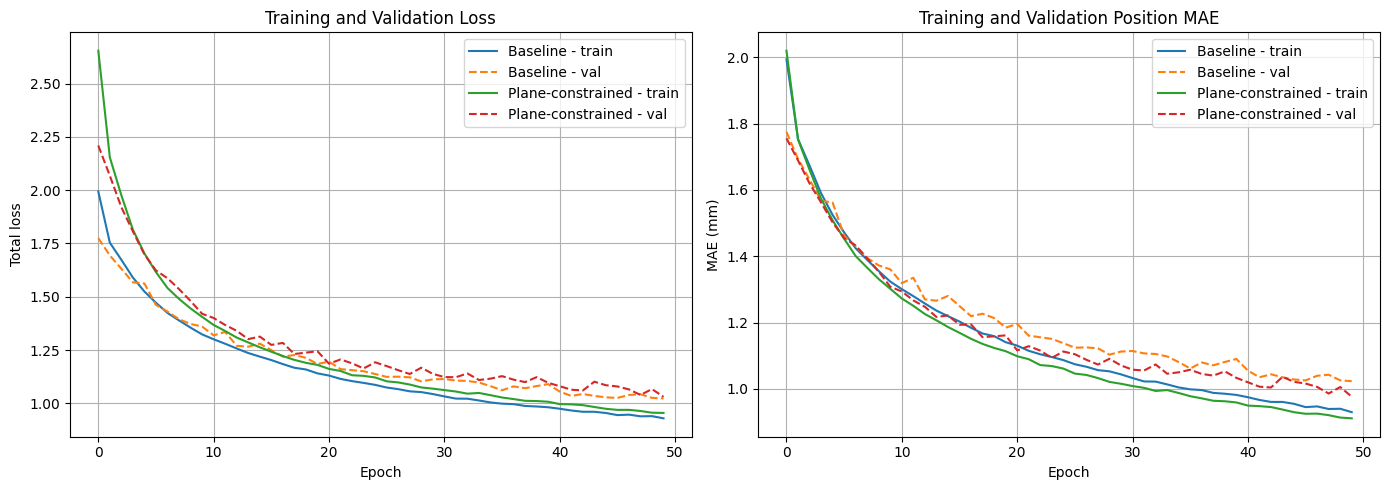

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history["loss"], label="Baseline - train")
axes[0].plot(history_baseline.history["val_loss"], label="Baseline - val", linestyle="--")
axes[0].plot(history_plane.history["loss"], label="Plane-constrained - train")
axes[0].plot(history_plane.history["val_loss"], label="Plane-constrained - val", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_baseline.history["mae"], label="Baseline - train")
axes[1].plot(history_baseline.history["val_mae"], label="Baseline - val", linestyle="--")
axes[1].plot(history_plane.history["mae"], label="Plane-constrained - train")
axes[1].plot(history_plane.history["val_mae"], label="Plane-constrained - val", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("Training and Validation Position MAE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 8. Test-set evaluation

Predict with both models on the held-out test set, then compare:
1. Overall 3D reconstruction error (does the plane constraint actually help?)
2. Per-coordinate error
3. How close predictions actually land to their event plane


In [15]:
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_plane = plane_model.predict(X_test_scaled)

print("y_test shape:        ", y_test.shape)
print("y_pred_baseline shape:", y_pred_baseline.shape)
print("y_pred_plane shape:   ", y_pred_plane.shape)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
y_test shape:         (990, 3)
y_pred_baseline shape: (990, 3)
y_pred_plane shape:    (990, 3)


In [16]:
def summarise_error(name, y_true, y_pred):
    err = np.linalg.norm(y_pred - y_true, axis=1)
    return {
        "model": name,
        "mean_error_mm": np.mean(err),
        "median_error_mm": np.median(err),
        "std_error_mm": np.std(err),
        "max_error_mm": np.max(err),
    }

summary = pd.DataFrame([
    summarise_error("Baseline (MAE only)", y_test, y_pred_baseline),
    summarise_error("Plane-constrained", y_test, y_pred_plane),
]).set_index("model")

summary


,mean_error_mm,median_error_mm,std_error_mm,max_error_mm
model,,,,
Baseline (MAE only),2.062068,1.866649,1.06320,8.793680
Plane-constrained,1.932274,1.714825,1.05956,7.972907


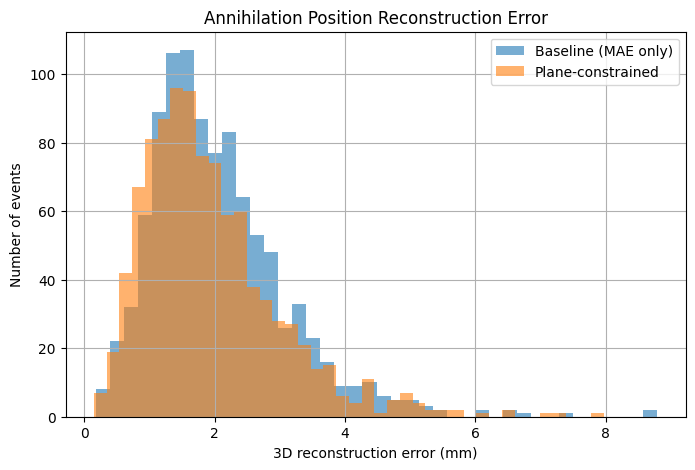

In [17]:
reconstruction_error_baseline = np.linalg.norm(y_pred_baseline - y_test, axis=1)
reconstruction_error_plane = np.linalg.norm(y_pred_plane - y_test, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error_baseline, bins=40, alpha=0.6, label="Baseline (MAE only)")
plt.hist(reconstruction_error_plane, bins=40, alpha=0.6, label="Plane-constrained")
plt.xlabel("3D reconstruction error (mm)")
plt.ylabel("Number of events")
plt.title("Annihilation Position Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()


### Did the plane constraint actually pull predictions towards the plane?

This checks the thing `plane_loss` was directly optimising: the perpendicular
distance from each *predicted* point to its own event's plane, for both models.
If the constraint is working, `plane_model` should show noticeably smaller
plane-distances than `baseline_model`.


In [18]:
def distance_to_plane(y_pred, plane):
    plane_point = plane[:, 0:3]
    plane_normal = plane[:, 3:6]
    plane_normal = plane_normal / (
        np.linalg.norm(plane_normal, axis=1, keepdims=True) + 1e-8
    )
    displacement = y_pred - plane_point
    return np.abs(np.sum(displacement * plane_normal, axis=1))


plane_dist_baseline = distance_to_plane(y_pred_baseline, plane_test)
plane_dist_plane = distance_to_plane(y_pred_plane, plane_test)

print("Baseline - mean/median distance to plane (mm):",
      np.mean(plane_dist_baseline), "/", np.median(plane_dist_baseline))
print("Plane-constrained - mean/median distance to plane (mm):",
      np.mean(plane_dist_plane), "/", np.median(plane_dist_plane))


Baseline - mean/median distance to plane (mm): 0.7270945201910172 / 0.6312335091435228
Plane-constrained - mean/median distance to plane (mm): 0.5565178150850767 / 0.46357243511092805


## 9. Detailed diagnostics for the plane-constrained model

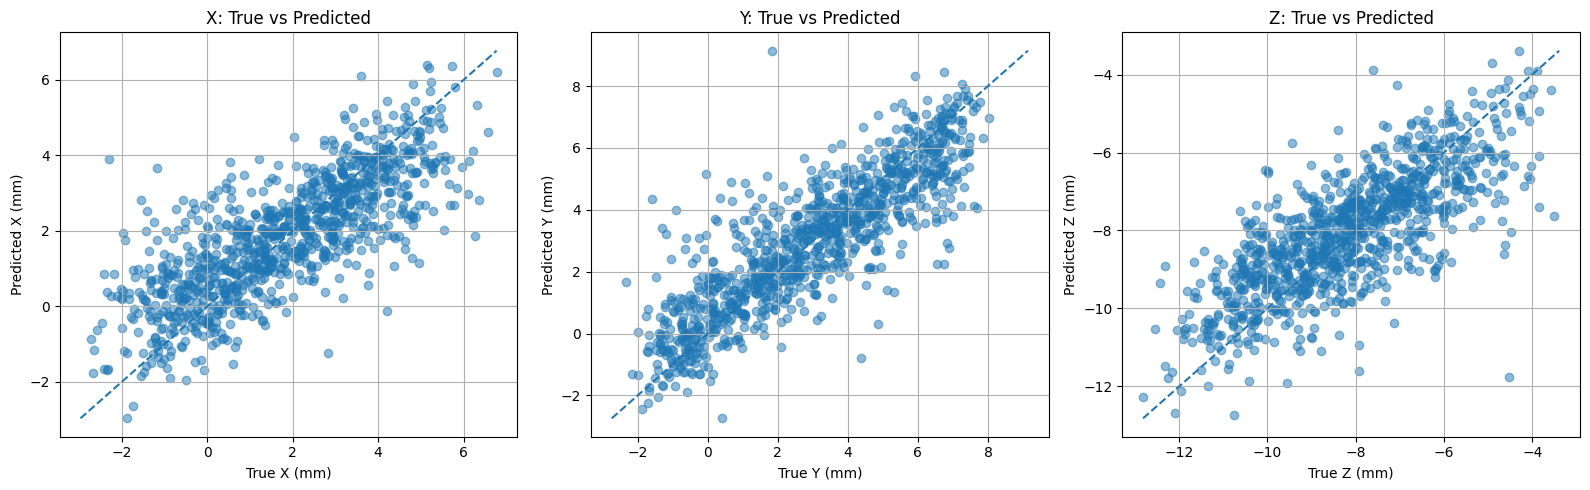

X MAE: 0.9733270872374903
Y MAE: 0.9697075153494047
Z MAE: 0.9389561486966682


In [19]:
y_pred = y_pred_plane  # from here on, inspect the plane-constrained model in detail
residuals = y_pred - y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
coordinates = ["X", "Y", "Z"]

for i, coord in enumerate(coordinates):
    axes[i].scatter(y_test[:, i], y_pred[:, i], alpha=0.5)

    min_val = min(y_test[:, i].min(), y_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle="--")

    axes[i].set_xlabel(f"True {coord} (mm)")
    axes[i].set_ylabel(f"Predicted {coord} (mm)")
    axes[i].set_title(f"{coord}: True vs Predicted")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

print("X MAE:", np.mean(np.abs(residuals[:, 0])))
print("Y MAE:", np.mean(np.abs(residuals[:, 1])))
print("Z MAE:", np.mean(np.abs(residuals[:, 2])))


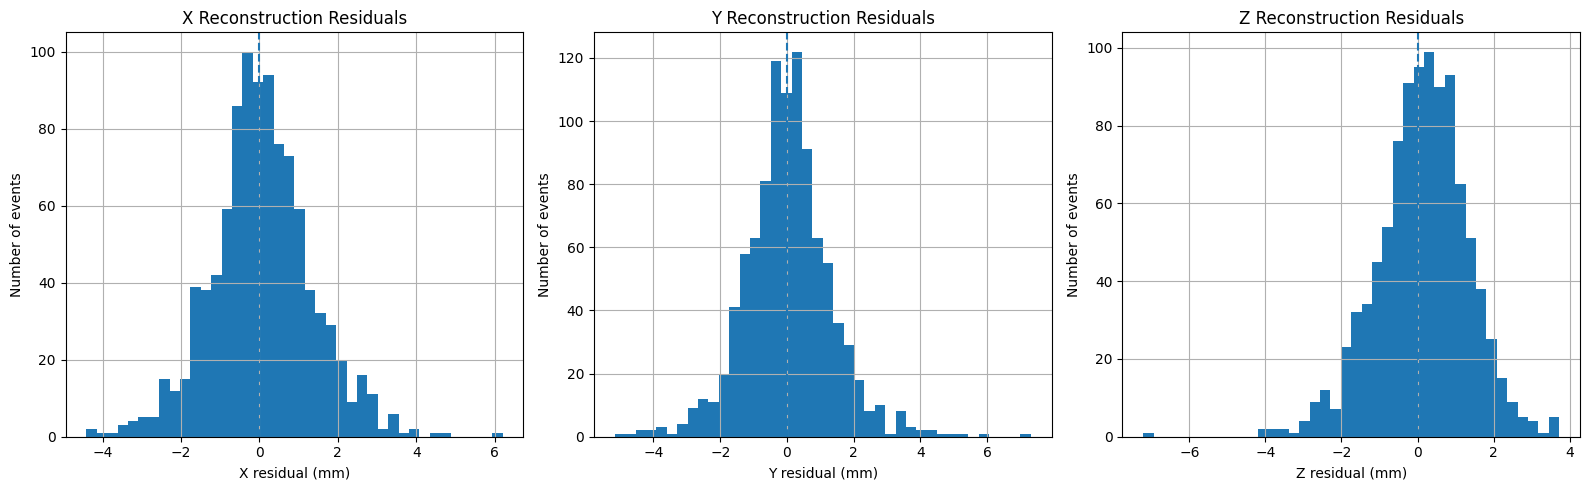

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, coord in enumerate(coordinates):
    axes[i].hist(residuals[:, i], bins=40)
    axes[i].axvline(0, linestyle="--")
    axes[i].set_xlabel(f"{coord} residual (mm)")
    axes[i].set_ylabel("Number of events")
    axes[i].set_title(f"{coord} Reconstruction Residuals")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


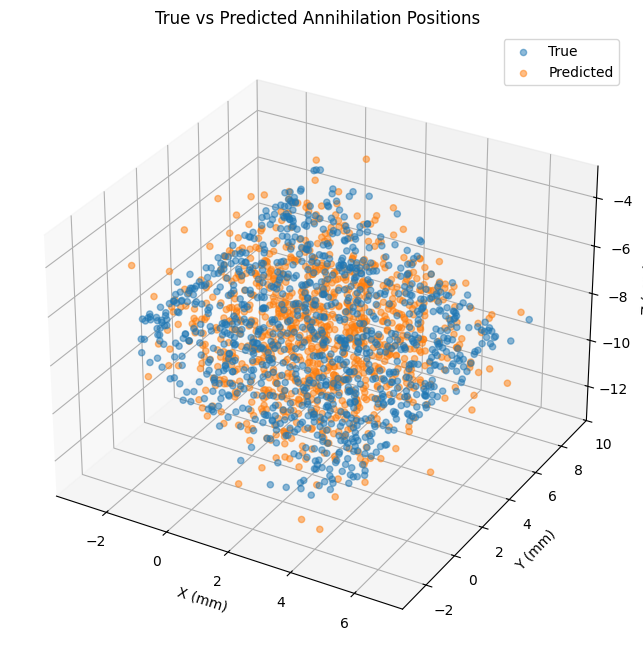

In [21]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(y_test[:, 0], y_test[:, 1], y_test[:, 2], alpha=0.5, label="True")
ax.scatter(y_pred[:, 0], y_pred[:, 1], y_pred[:, 2], alpha=0.5, label="Predicted")

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("True vs Predicted Annihilation Positions")
ax.legend()

plt.show()


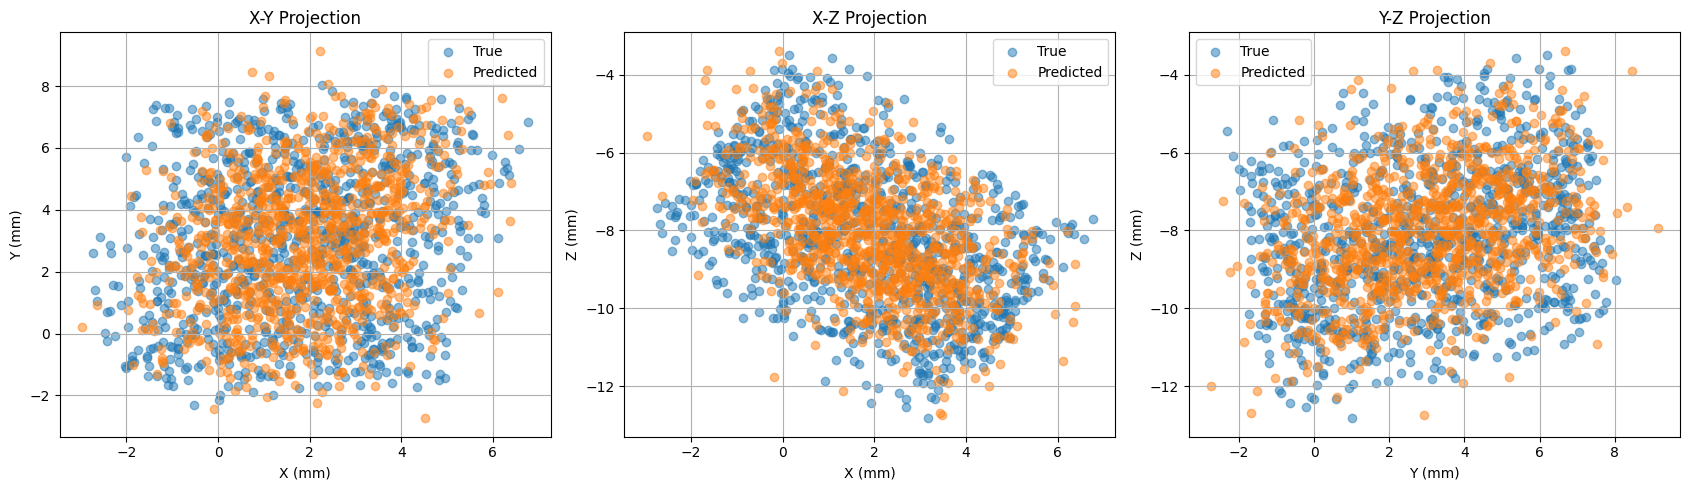

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test[:, i], y_test[:, j], alpha=0.5, label="True")
    ax.scatter(y_pred[:, i], y_pred[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


## 10. A handful of individual events, in 3D

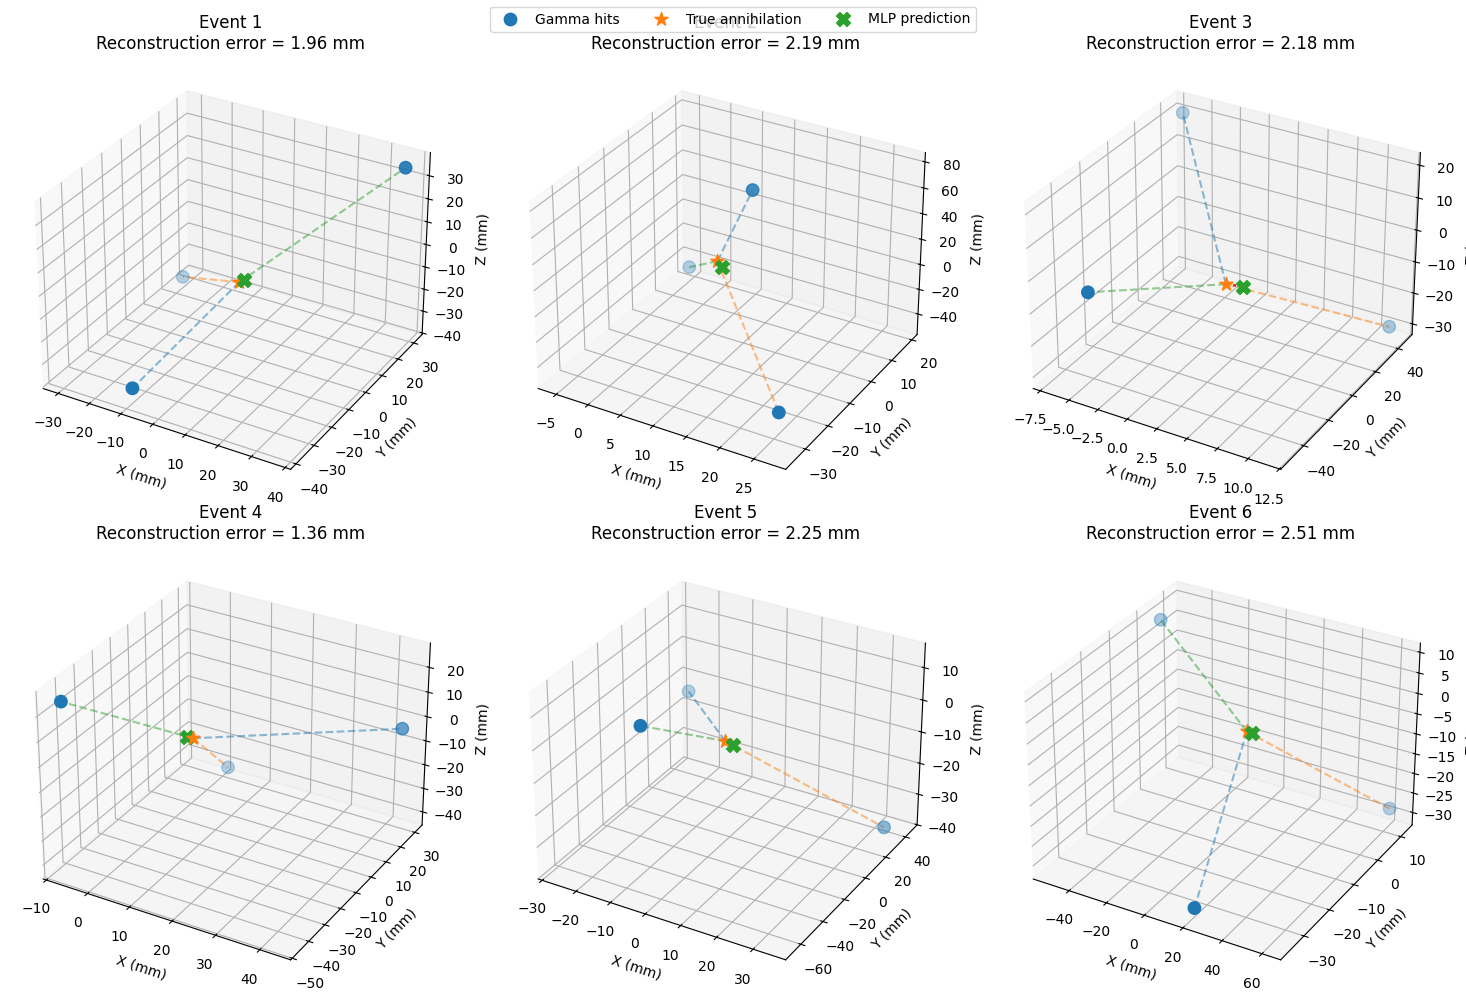

In [23]:
n_events = min(6, len(X_test))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    hits = np.array([X_test[i, 0:3], X_test[i, 4:7], X_test[i, 8:11]])
    true_pos = y_test[i]
    pred_pos = y_pred[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="MLP prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i+1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()


In [24]:
#COMPARING TO BASELINE OF DEFAULTING TO MEAN

# Calculate the mean annihilation position
# using TRAINING data only
mean_position = np.mean(y_train, axis=0)

print("Mean annihilation position:")
print(f"X = {mean_position[0]:.3f} mm")
print(f"Y = {mean_position[1]:.3f} mm")
print(f"Z = {mean_position[2]:.3f} mm")


# Predict the same position for every test event
mean_predictions = np.tile(
    mean_position,
    (len(y_test), 1)
)


# ==========================================
# 3D ERROR FOR MEAN BASELINE
# ==========================================

mean_errors = np.sqrt(
    (mean_predictions[:, 0] - y_test[:, 0])**2 +
    (mean_predictions[:, 1] - y_test[:, 1])**2 +
    (mean_predictions[:, 2] - y_test[:, 2])**2
)

mean_3d_error = np.mean(mean_errors)
mean_median_error = np.median(mean_errors)

print("\n======================================")
print("MEAN POSITION BASELINE")
print("======================================")

print(f"Mean 3D error   : {mean_3d_error:.3f} mm")
print(f"Median 3D error : {mean_median_error:.3f} mm")
print(f"Maximum error   : {np.max(mean_errors):.3f} mm")


# ==========================================
# MLP VS MEAN BASELINE
# ==========================================

mlp_errors = np.sqrt(
    (y_pred[:, 0] - y_test[:, 0])**2 +
    (y_pred[:, 1] - y_test[:, 1])**2 +
    (y_pred[:, 2] - y_test[:, 2])**2
)

print("\n======================================")
print("MLP VS MEAN BASELINE")
print("======================================")

print(f"MLP mean 3D error  : {np.mean(mlp_errors):.3f} mm")
print(f"Mean baseline      : {np.mean(mean_errors):.3f} mm")

improvement = (
    (np.mean(mean_errors) - np.mean(mlp_errors))
    / np.mean(mean_errors)
    * 100
)

print(f"Improvement        : {improvement:.1f}%")


Mean annihilation position:
X = 1.825 mm
Y = 3.000 mm
Z = -8.142 mm

MEAN POSITION BASELINE
Mean 3D error   : 3.548 mm
Median 3D error : 3.669 mm
Maximum error   : 6.416 mm

MLP VS MEAN BASELINE
MLP mean 3D error  : 1.932 mm
Mean baseline      : 3.548 mm
Improvement        : 45.5%
